# **Blood Donar Prediction**

# PROBLEM STATEMENT
-> The dataset is related to blood donations and based on its structure, the goal is to create a classification model that predicts  whether a donor will donate blood in March 2007 based on their past donation hsitory.

1. Months since Last Donation
2. Number of Donations
3. Months since First Donation

-> The objective is to analyze the given dataset is:

1. Donation Patterns – How frequently do donors donate?
2. Time Between Donations – Does the gap between first and last donation impact future donations?
3. Total Number of Donations – Does donating frequently increase the likelihood of donating again?
4. Feature Importance – Which factors contribute the most to predicting future donations?

# DOMAIN ANALYSIS AND ATTRIBUTES
This project come under Blood Donation prediction domain focusing on predicting individual Blood donor based on the key attributes such as,

1. Unnamed: 0 -> This column represent the index column of the dataset.

2. Months since last donation -> This column represent the number of months that have passed since a donor's most recent blood donation.  It shows how frequently a donor gives blood.

3. Number of Donations -> This column represent the total number of times a donor has donated blood. Identifies frequent Vs. occasional donors.

4. Total volume donated (c.c) -> This column represent the total amount of blood (in cubic centimeters) that a donor has donated over time.  Its is directly proportional to the "Number of donations column".

5. Month since first donation -> This column represents the number of months that have passed since a donor's first blood donation.  It helps in identifying new Vs. long term donors.

6. Made donation in march 2007 -> The Made donation in march 2007 cloumn is a binary indicator (0 or1) that shows whether a donor gave blood in March 2007.  It helps analyze donor activity in a specific month.


# 1. IMPORTING LIBRARIES

In [ ]:
#Importing pandas library to perform many task in dataset.
import pandas as pd

#Importing numpy library used to perform mathematical operation and scientific computing.
import numpy as np

#Importing matplotlib library used to create graphs,chart, and other visualization
import matplotlib.pyplot as plt

#Importing seaborn library used to perform making stastical graphics
import seaborn as sns

#Importing warnings for disable warnings from the code
import warnings
#to ignore the warnings
warnings.filterwarnings('ignore')

#Importing ProfileReport
from ydata_profiling import ProfileReport
# MinMaxScaler for feature scaling to bring values within a specific range
from sklearn.preprocessing import MinMaxScaler

# Importing train_test_split for splitting data into training and testing sets for model evaluation
from sklearn.model_selection import train_test_split

# Importing LogisticRegression
from sklearn.linear_model import LogisticRegression

# Importing DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Importing an ensemble model RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Importing an advanced boosting model GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Importing an efficient and optimized version of gradient- XGBoost (Classifier)
from xgboost import XGBClassifier

# Importing SVC model from sklearn
from sklearn.svm import SVC

# Importing KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

# Importing GridSearchCV for Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Importing RandomizedSearchCV for hyperparameter tuning using randomized search
from sklearn.model_selection import RandomizedSearchCV

# Importing Multi-layer Perceptron (MLP) Classifier
from sklearn.neural_network import MLPClassifier

# Importing performance metrics for model evaluation
# accuracy_score,confusion_matrix,classification_report,etc.
from sklearn.metrics import *

# 2. LOADING THE DATASET

In [ ]:
#loading the data
Data=pd.read_csv('Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv')
Data

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0
...,...,...,...,...,...,...
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0


# 3. BASIC CHECKS

In [ ]:
# Dropping the Unnamed: 0 column
Data.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
# Calling the dataset
Data

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
571,23,1,250,23,0
572,16,3,750,86,0
573,21,2,500,52,0
574,39,1,250,39,0


In [ ]:
# Extract first 10 row in the dataset
Data.head(10)

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
5,4,4,1000,4,0
6,2,7,1750,14,1
7,1,12,3000,35,0
8,5,46,11500,98,1
9,0,3,750,4,0


In [ ]:
# Extract last 10 rows in the dataset
Data.tail(10)

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
566,23,1,250,23,1
567,23,1,250,23,0
568,23,1,250,23,0
569,23,1,250,23,0
570,23,1,250,23,0
571,23,1,250,23,0
572,16,3,750,86,0
573,21,2,500,52,0
574,39,1,250,39,0
575,72,1,250,72,0


In [ ]:
# Checking the number of rows and columns of the data
Data.shape

(576, 5)

In [ ]:
# Checking the basic information of the data
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Months since Last Donation   576 non-null    int64
 1   Number of Donations          576 non-null    int64
 2   Total Volume Donated (c.c.)  576 non-null    int64
 3   Months since First Donation  576 non-null    int64
 4   Made Donation in March 2007  576 non-null    int64
dtypes: int64(5)
memory usage: 22.6 KB


In [ ]:
# Checking the statistical information of the numerical column in the data
Data.describe()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000
mean,9.439236,5.427083,1356.770833,34.050347,0.239583
std,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.000000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,49.250000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


In [ ]:
#Extract the columns name
Data.columns

Index(['Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='object')

In [ ]:
# Checking the index of the data
Data.index

RangeIndex(start=0, stop=576, step=1)

In [ ]:
# Checking the unique values for all the columns in the data
for i in Data:
    print(f"                             {i.title()}                      ")
    print(f"* The number of unique values in {i} column :",Data[i].nunique())
    print(">>",Data[i].unique())
    print('==================================================================================')

                             Months Since Last Donation                      
* The number of unique values in Months since Last Donation column : 29
>> [ 2  0  1  4  5  3 12  6 11  9 10 13 14  8  7 16 23 21 18 22 26 35 74 15
 20 17 25 39 72]
                             Number Of Donations                      
* The number of unique values in Number of Donations column : 29
>> [50 13 16 20 24  4  7 12 46  3 10  6  5 14 15 11  8  9  2 19 17  1 22 18
 38 43 44 21 33]
                             Total Volume Donated (C.C.)                      
* The number of unique values in Total Volume Donated (c.c.) column : 29
>> [12500  3250  4000  5000  6000  1000  1750  3000 11500   750  2500  1500
  1250  3500  3750  2750  2000  2250   500  4750  4250   250  5500  4500
  9500 10750 11000  5250  8250]
                             Months Since First Donation                      
* The number of unique values in Months since First Donation column : 75
>> [98 28 35 45 77  4 14 47 15 11 48 49 16 

In [ ]:
# checking the value counts of all the columns in the data
for i in Data:
    print(f"                             {i.title()}                      ")
    print(Data[i].value_counts())
    print('==================================================================================')

                             Months Since Last Donation                      
Months since Last Donation
2     140
4     115
14     60
11     60
16     48
21     37
23     36
9      17
3      10
1       9
8       5
7       5
12      5
13      4
0       4
6       4
10      3
5       2
18      2
20      1
39      1
25      1
17      1
26      1
15      1
74      1
35      1
22      1
72      1
Name: count, dtype: int64
                             Number Of Donations                      
Number of Donations
1     118
2      85
3      68
5      53
4      49
6      42
7      32
8      27
9      20
11     16
10     11
12      9
16      8
14      8
13      7
17      4
15      3
19      2
24      2
20      2
22      2
43      1
21      1
44      1
50      1
38      1
18      1
46      1
33      1
Name: count, dtype: int64
                             Total Volume Donated (C.C.)                      
Total Volume Donated (c.c.)
250      118
500       85
750       68
1250      53
1000      49


# 4. HANDLING THE DUPLICATES

In [ ]:
# Checking the duplicates values
Data.duplicated().sum()

153

In [ ]:
# Duplicated rows
duplicate_rows=Data[Data.duplicated()]
duplicate_rows

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
16,2,6,1500,15,1
18,2,3,750,4,1
21,2,6,1500,16,1
27,4,10,2500,28,1
36,2,5,1250,16,0
...,...,...,...,...,...
567,23,1,250,23,0
568,23,1,250,23,0
569,23,1,250,23,0
570,23,1,250,23,0


In [ ]:
#Droping the duplicates
Data.drop_duplicates(inplace=True)

In [ ]:
#checking
Data.duplicated().sum()

0

# INSIGHTS
1. The dataset has 576 rows and 5 columns.
3. In the dataset unnnamed: 0 is droped.
2. There are 153 duplicated values  in the dataset.



# 5. EXPLORATORY DATA ANALYSIS (EDA)

## 5.1. PROFILE REPORT

In [ ]:
report=ProfileReport(Data,title="Profile Report")
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 5.2. UNIVARIATE ANALYSIS FOR NUMERICAL COLUMNS

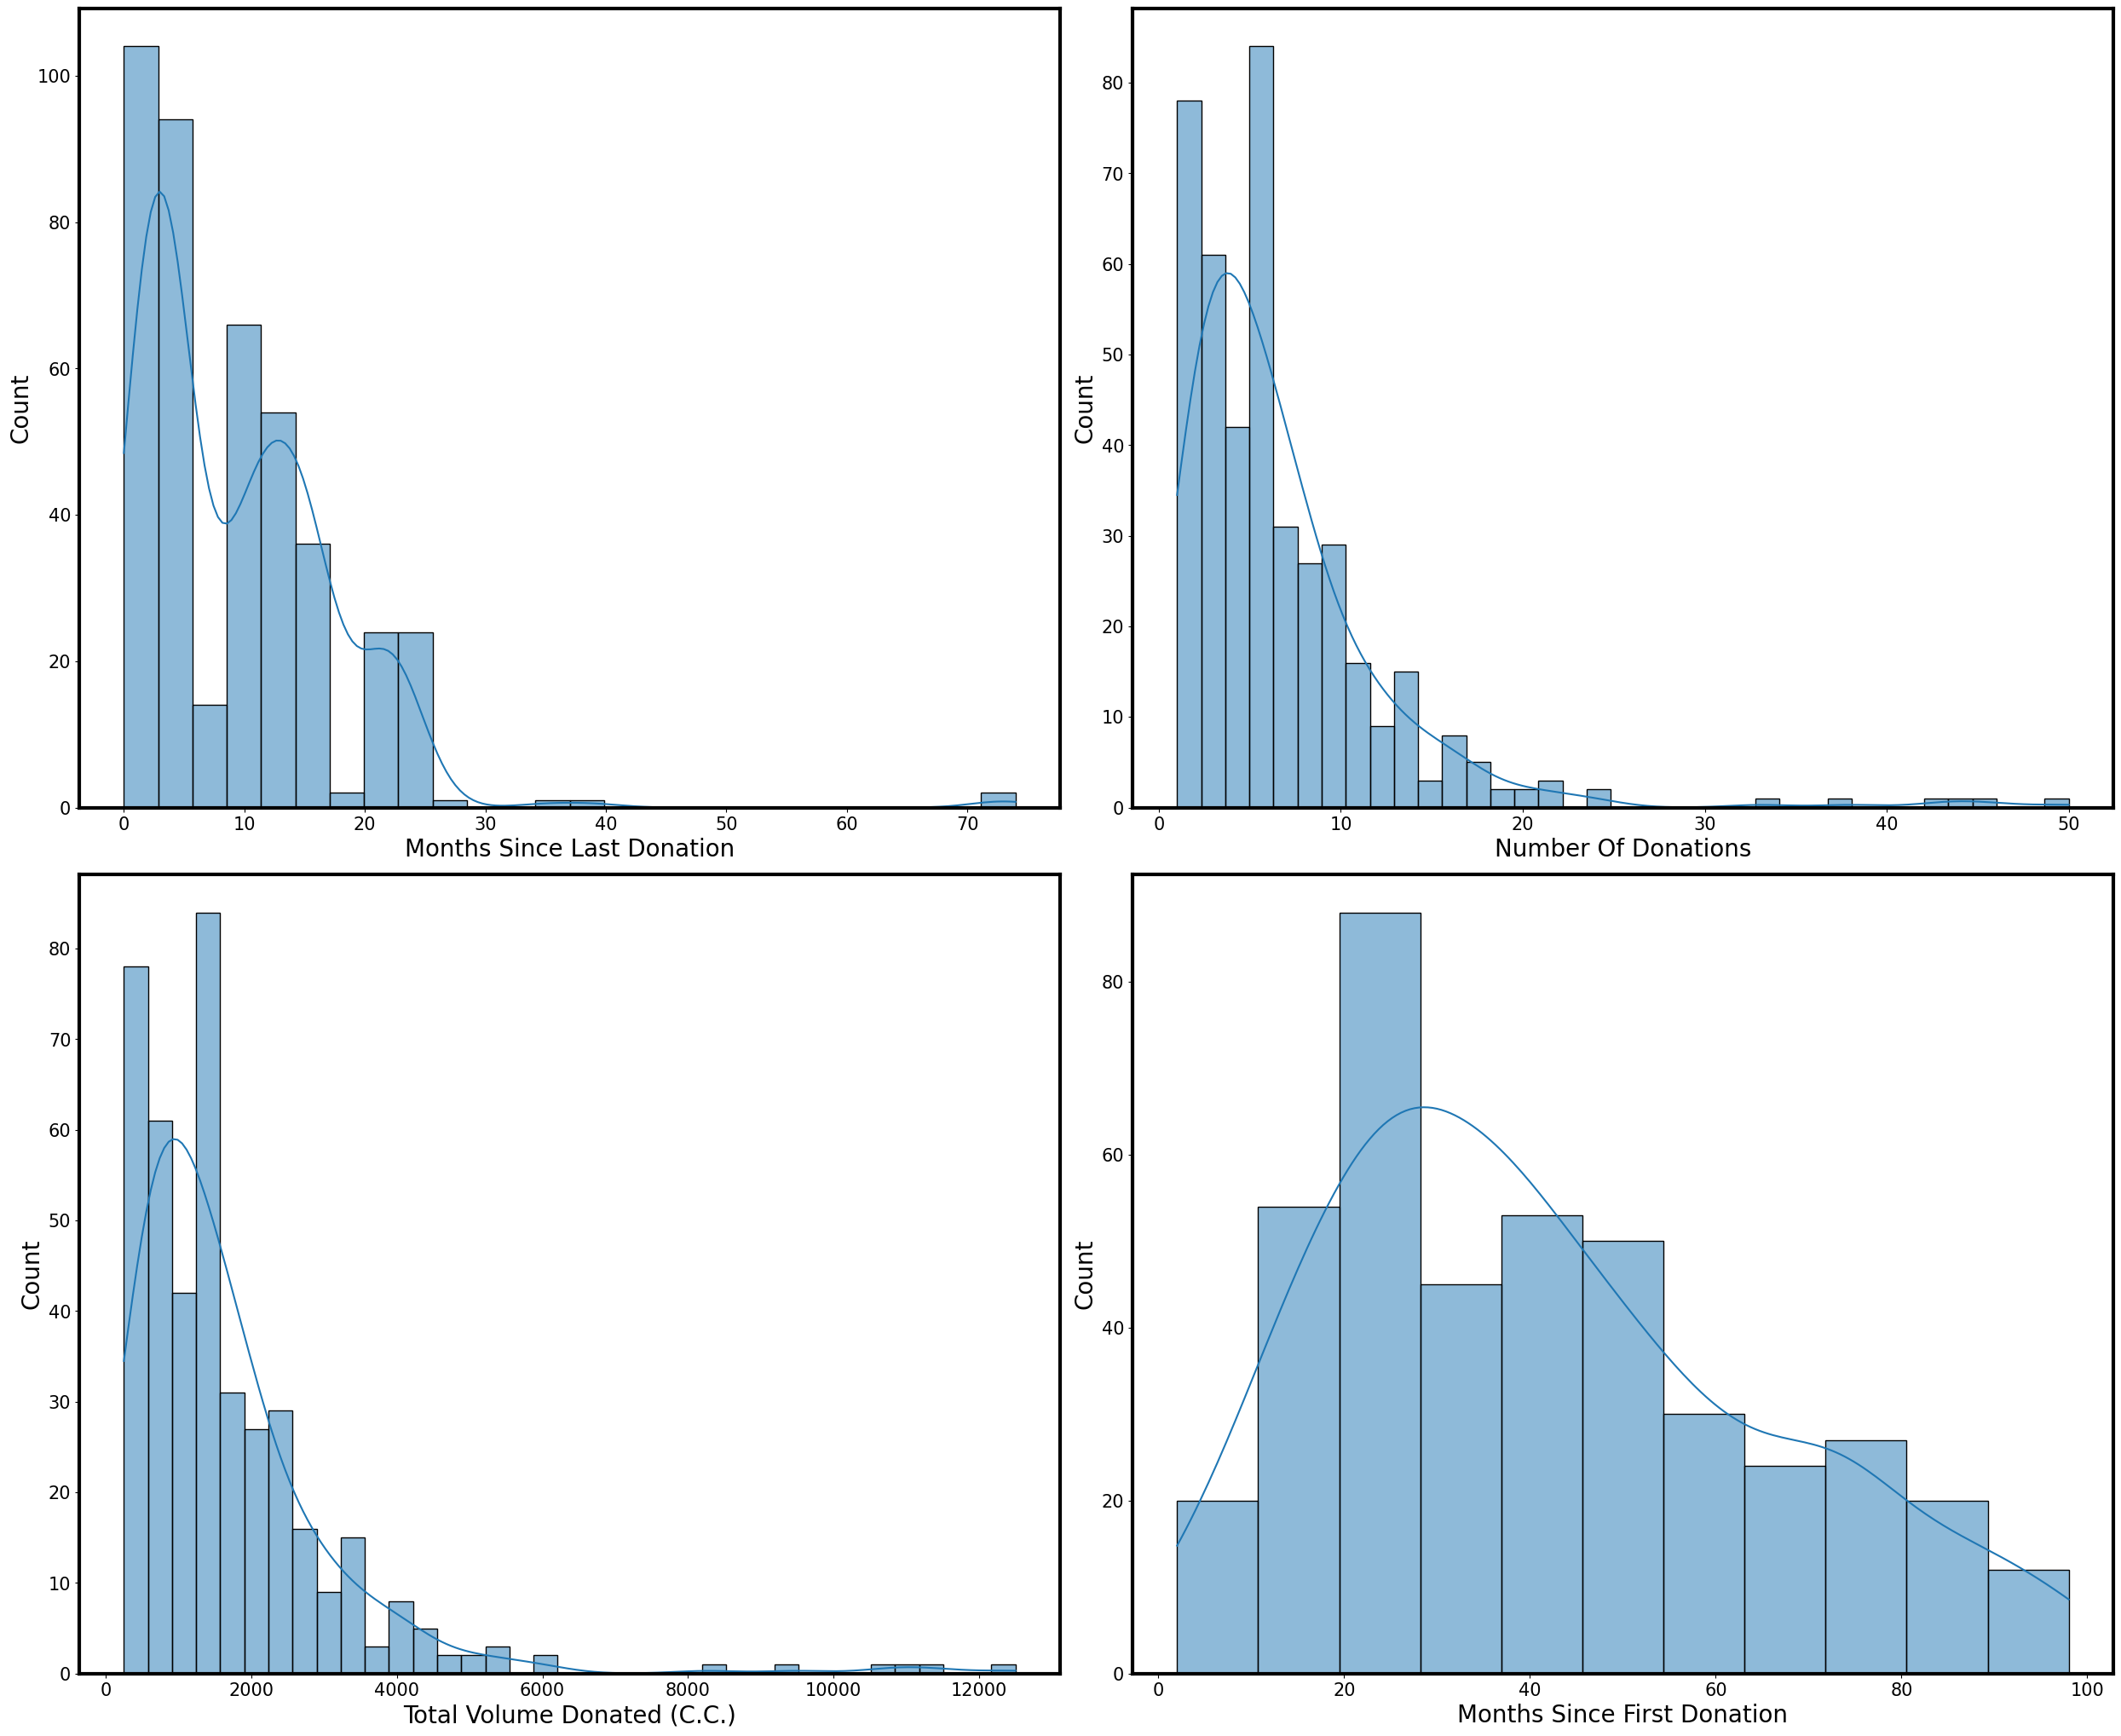

In [ ]:
#hisplot for numerical column
plt.figure(figsize=(25,30),facecolor="white")
pltnum =1

for i in Data.iloc[:,:-1]:
    if pltnum <=5:
        sp = plt.subplot(3,2,pltnum)
        sns.histplot(Data[i],kde=True)
        plt.xlabel(i.title(),fontsize=20)
        plt.ylabel("Count",fontsize=20)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        sp.spines['top'].set_linewidth(3)
        sp.spines['bottom'].set_linewidth(3)
        sp.spines['left'].set_linewidth(3)
        sp.spines['right'].set_linewidth(3)
    pltnum +=1
plt.tight_layout()
plt.show()

## 5.3. UNIVARIATE ANALYSIS FOR CATEGORICAL COLUMN

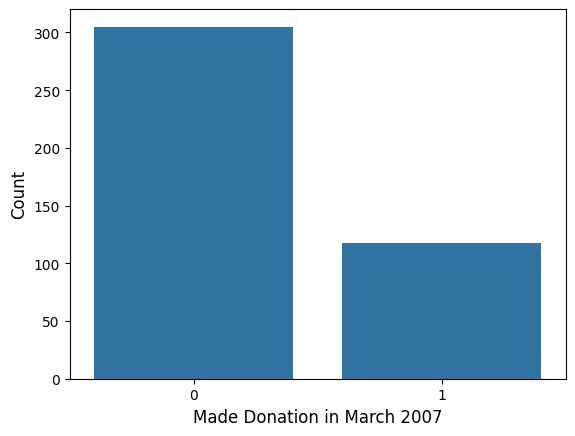

In [ ]:
#countplot for categorical column
sns.countplot(x=Data.iloc[:,-1])
plt.xlabel("Made Donation in March 2007",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [ ]:
Data["Made Donation in March 2007"].value_counts()

,count
Made Donation in March 2007,
0,305
1,118


## 5.4. BIVARIATE ANALYSIS

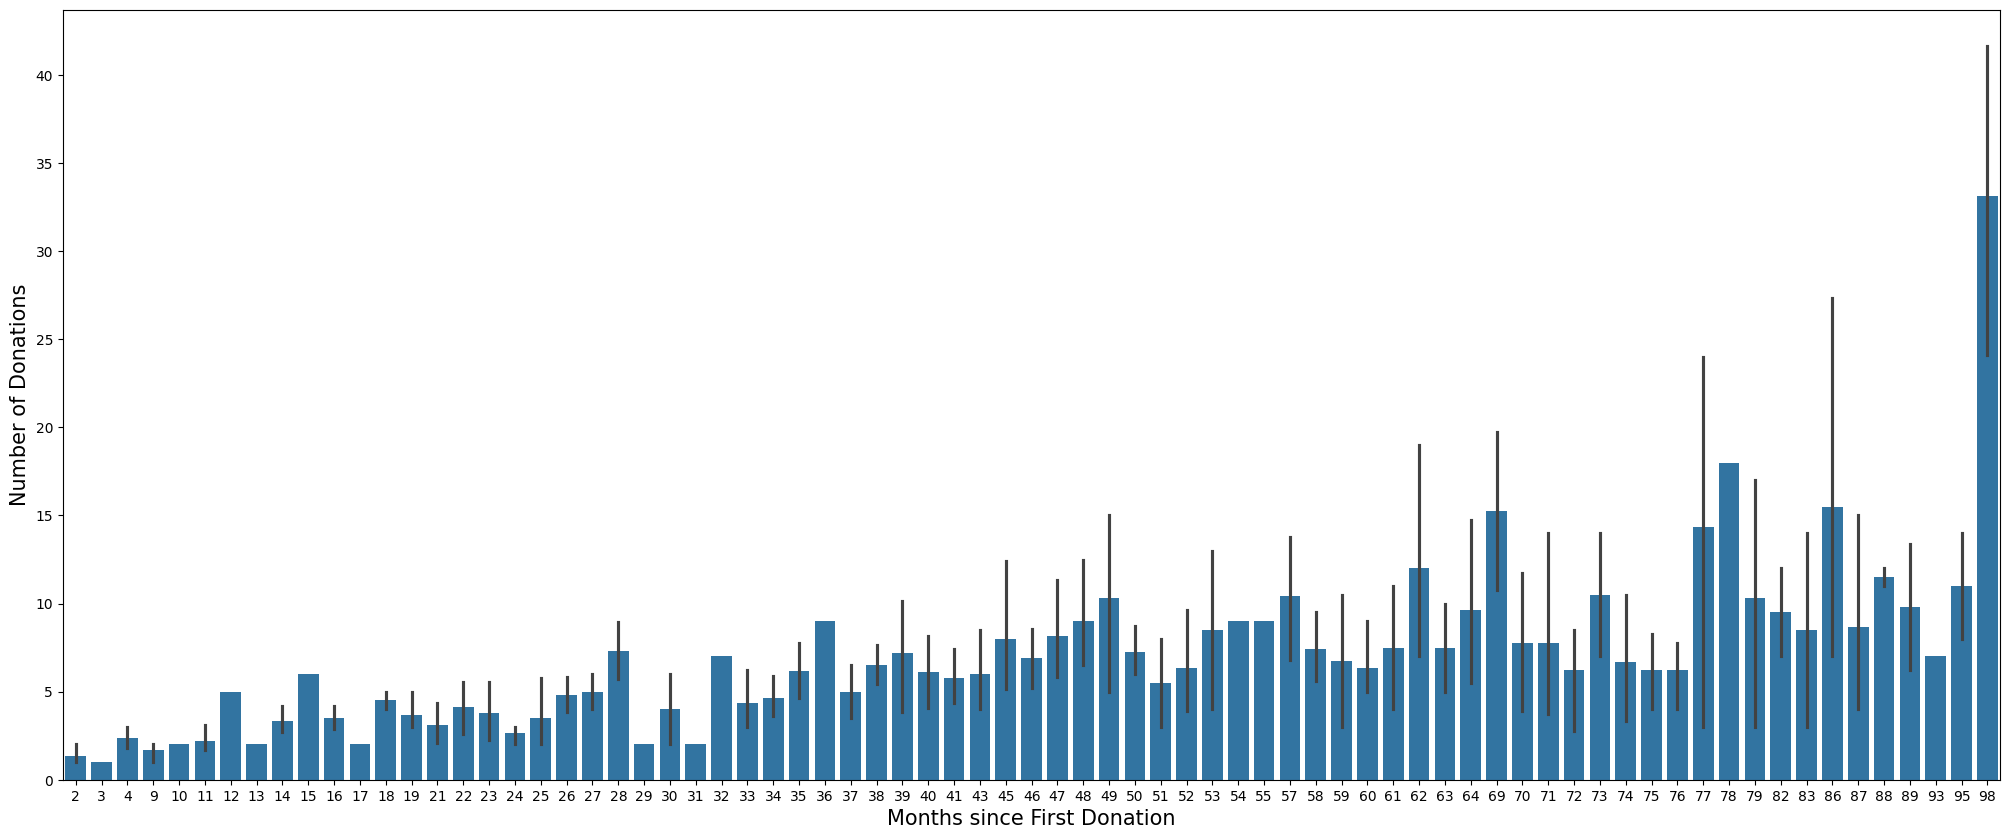

In [ ]:
#Months since First Donatin vs Number of Donations
plt.figure(figsize=(25,10),facecolor="white")
sns.barplot(x="Months since First Donation",y="Number of Donations",data=Data)
plt.xlabel("Months since First Donation",fontsize=15)
plt.ylabel("Number of Donations",fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

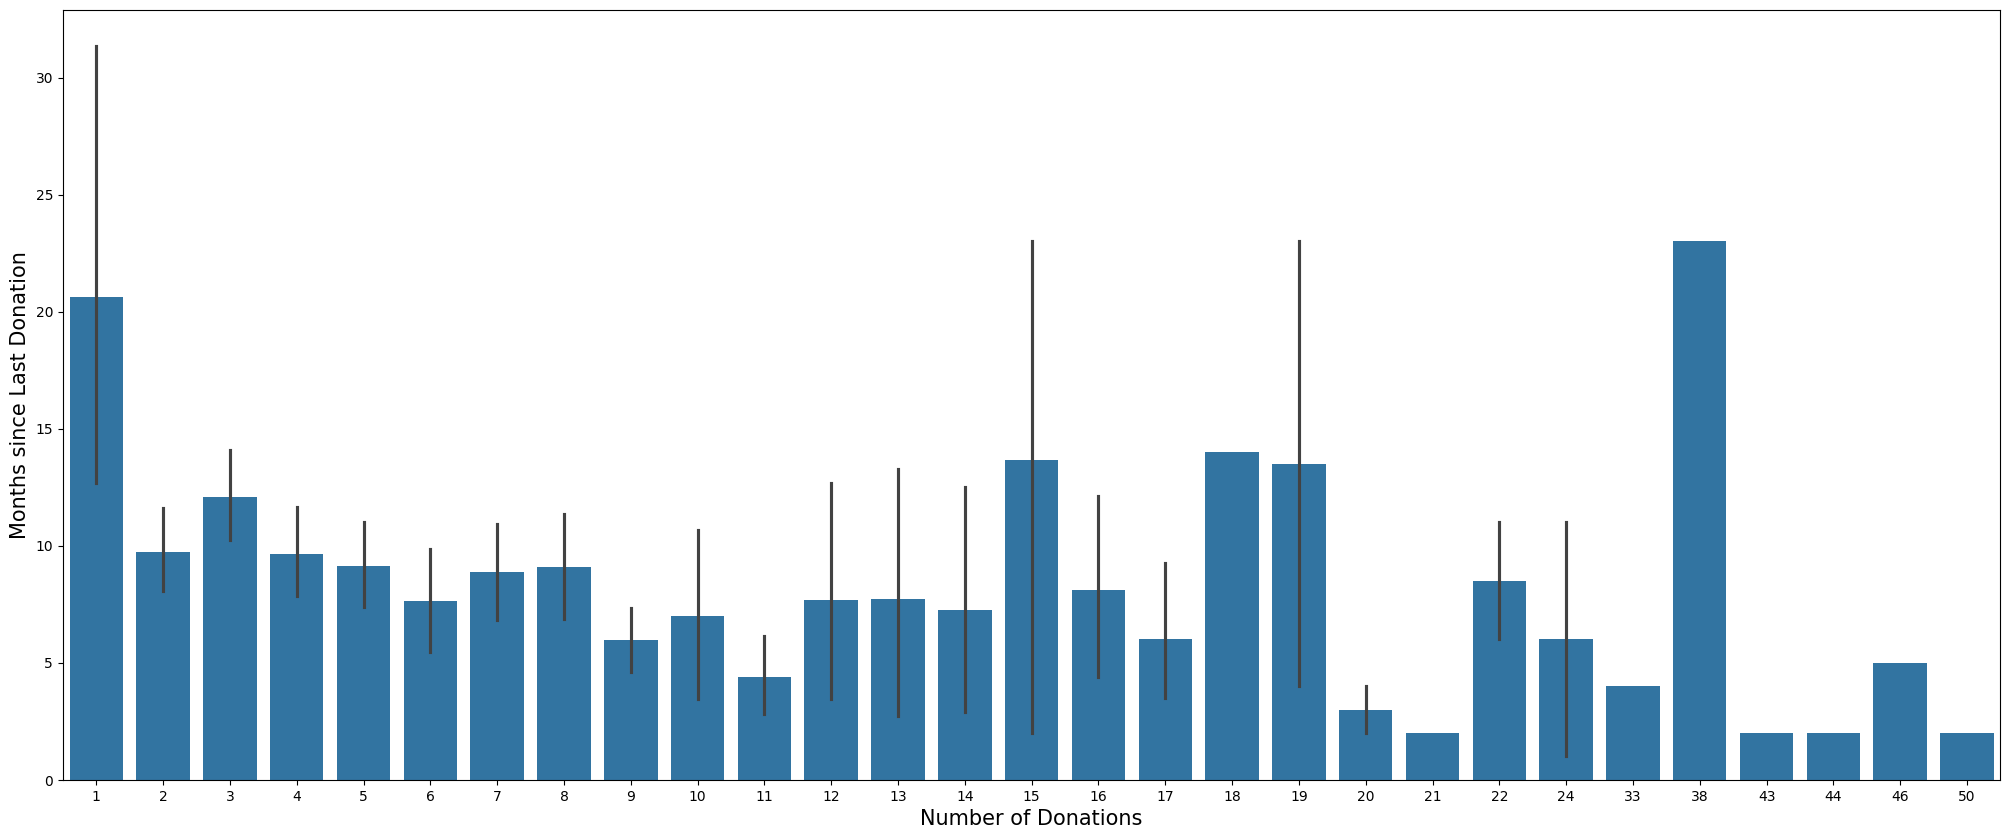

In [ ]:
#Number of Donations Vs Months since last Donation
plt.figure(figsize=(25,10),facecolor="white")
sns.barplot(x="Number of Donations",y="Months since Last Donation",data=Data)
plt.xlabel("Number of Donations",fontsize=15)
plt.ylabel("Months since Last Donation",fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

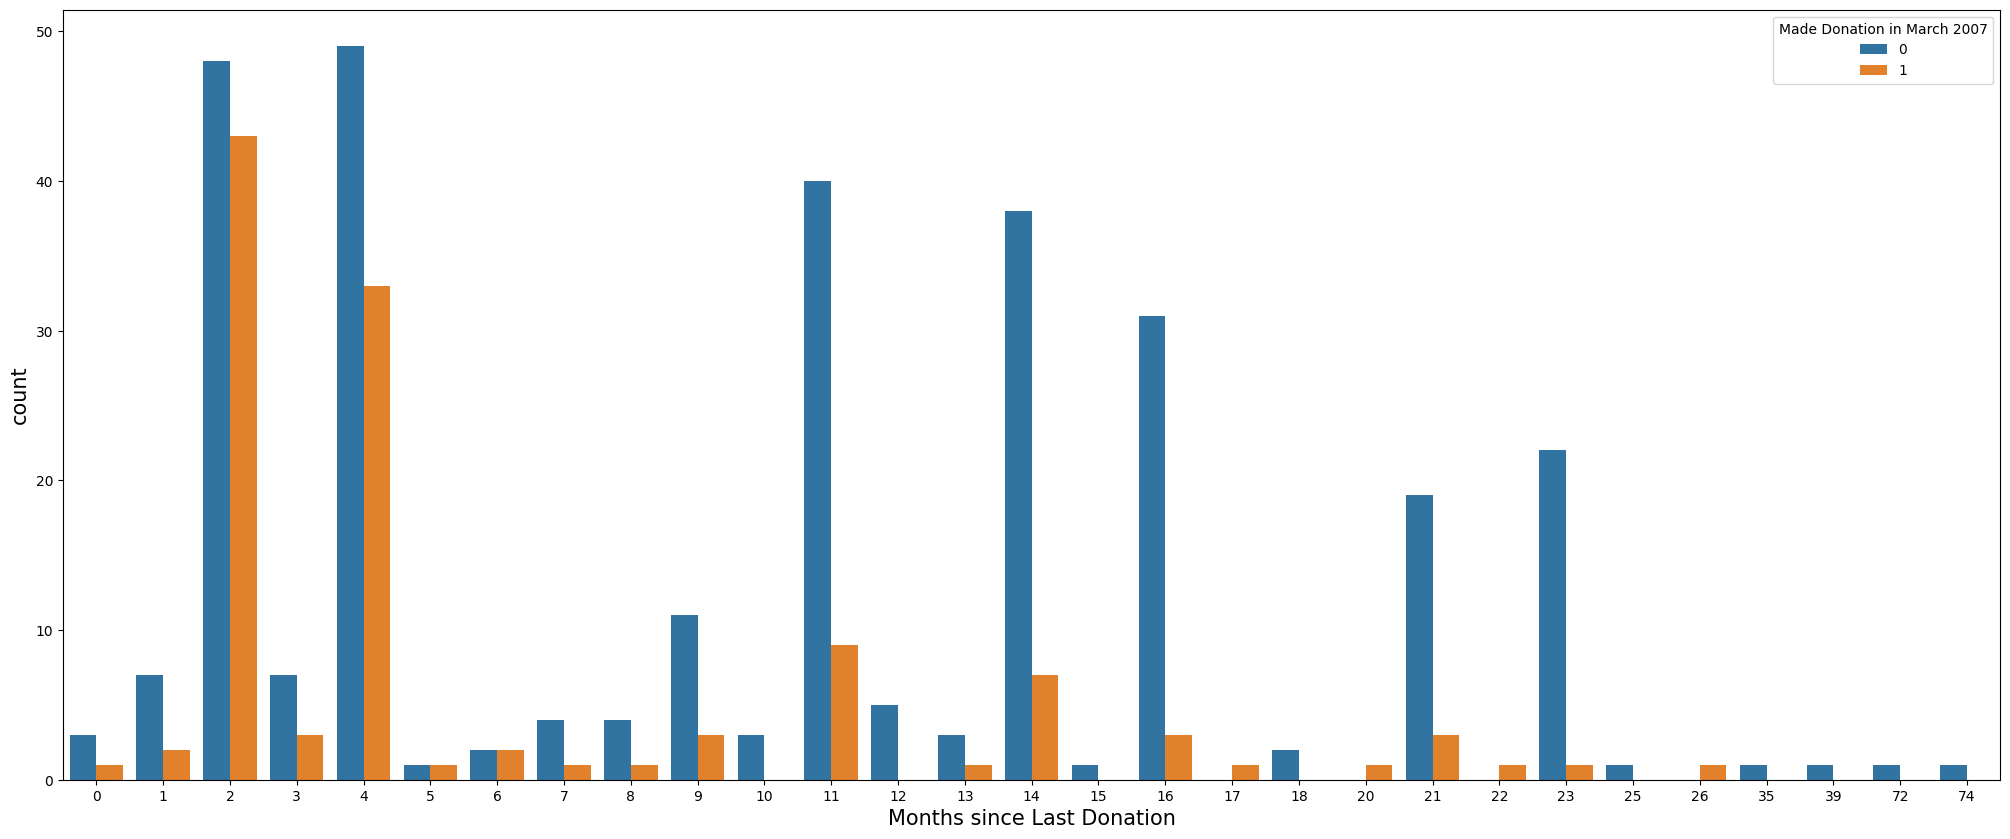

In [ ]:
#Months since last donations vs Made Donation in March 2007
plt.figure(figsize=(25,10),facecolor="white")
sns.countplot(x="Months since Last Donation",hue="Made Donation in March 2007",data=Data)
plt.xlabel("Months since Last Donation",fontsize=15)
plt.ylabel("count",fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

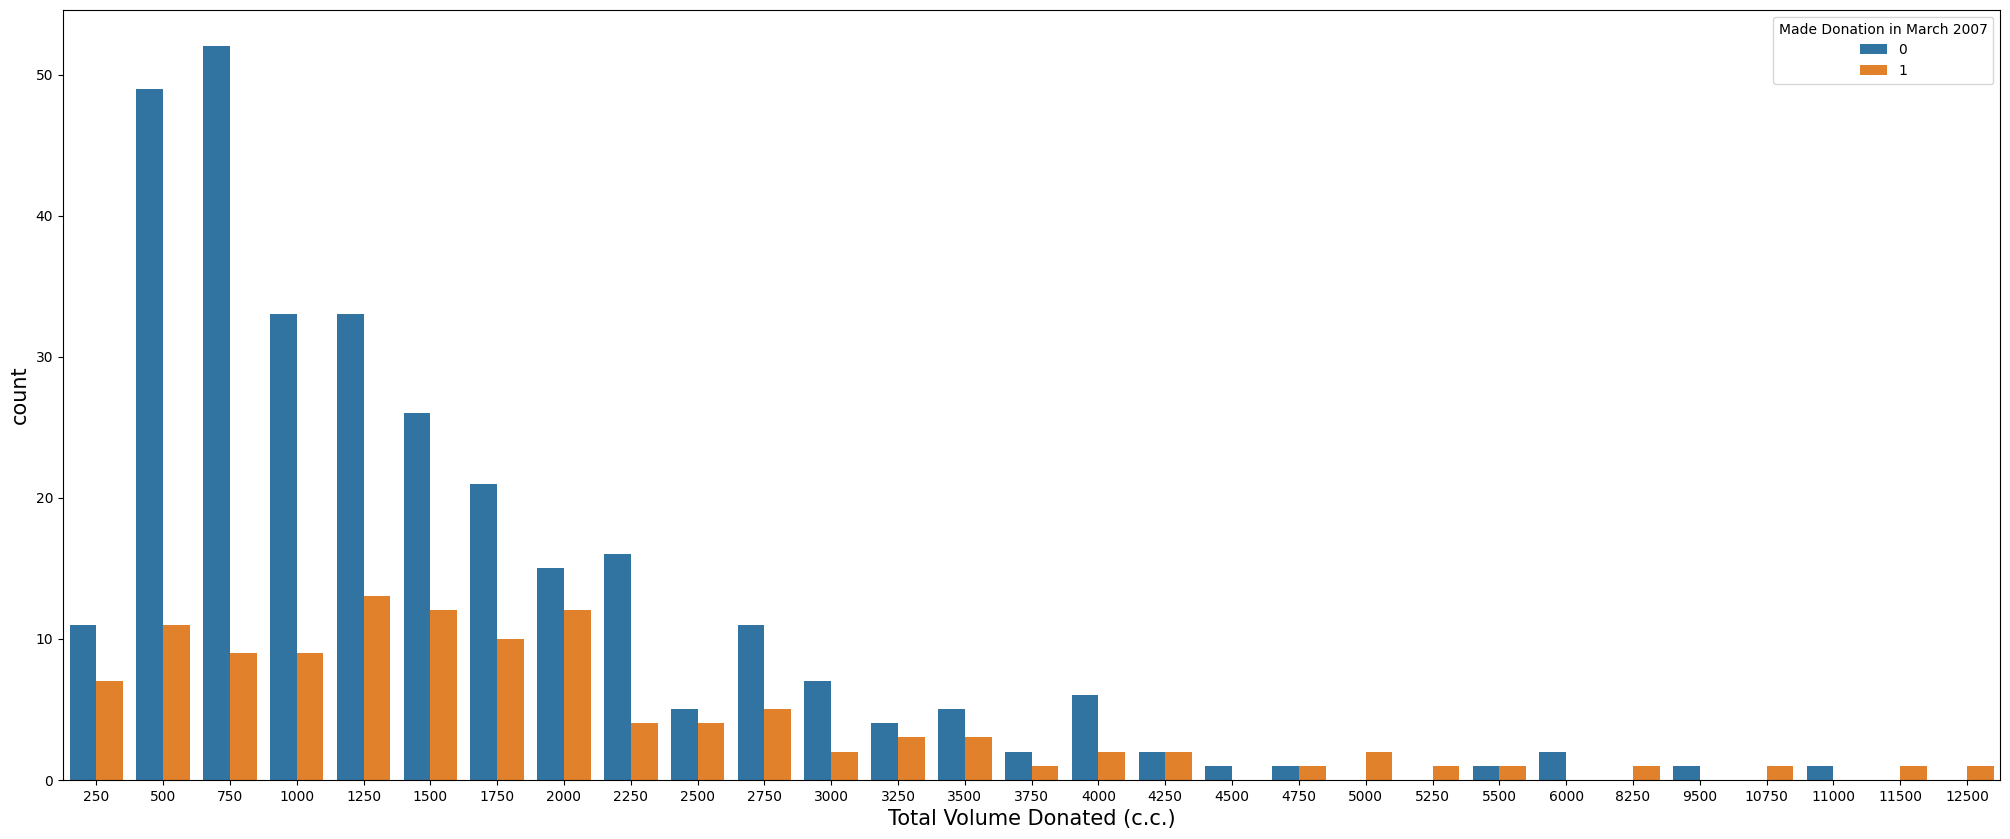

In [ ]:
# Total Volume Donated (c.c.) vs Made Donation in March 2007
plt.figure(figsize=(25,10),facecolor="white")
sns.countplot(x="Total Volume Donated (c.c.)",hue="Made Donation in March 2007",data=Data)
plt.xlabel("Total Volume Donated (c.c.)",fontsize=15)
plt.ylabel("count",fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

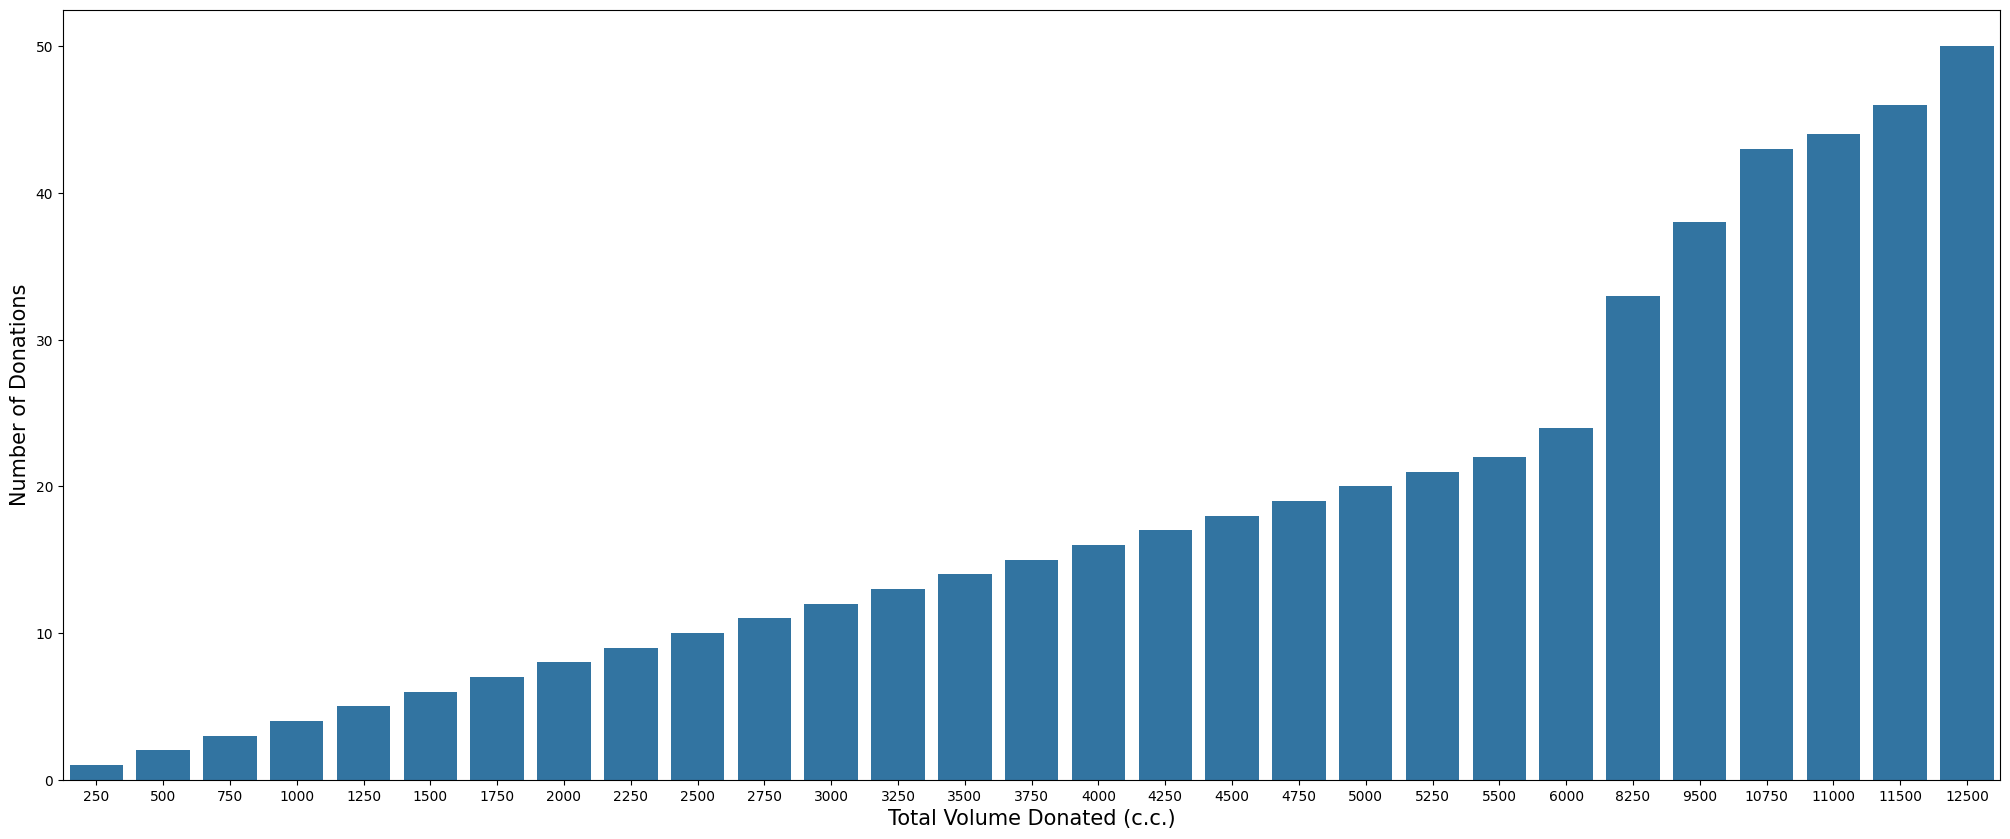

In [ ]:
#Total Volume Donated (c.c.) Vs Number of Donations
plt.figure(figsize=(25,10),facecolor="white")
sns.barplot(x="Total Volume Donated (c.c.)",y="Number of Donations",data=Data)
plt.xlabel("Total Volume Donated (c.c.)",fontsize=15)
plt.ylabel("Number of Donations",fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show() #1

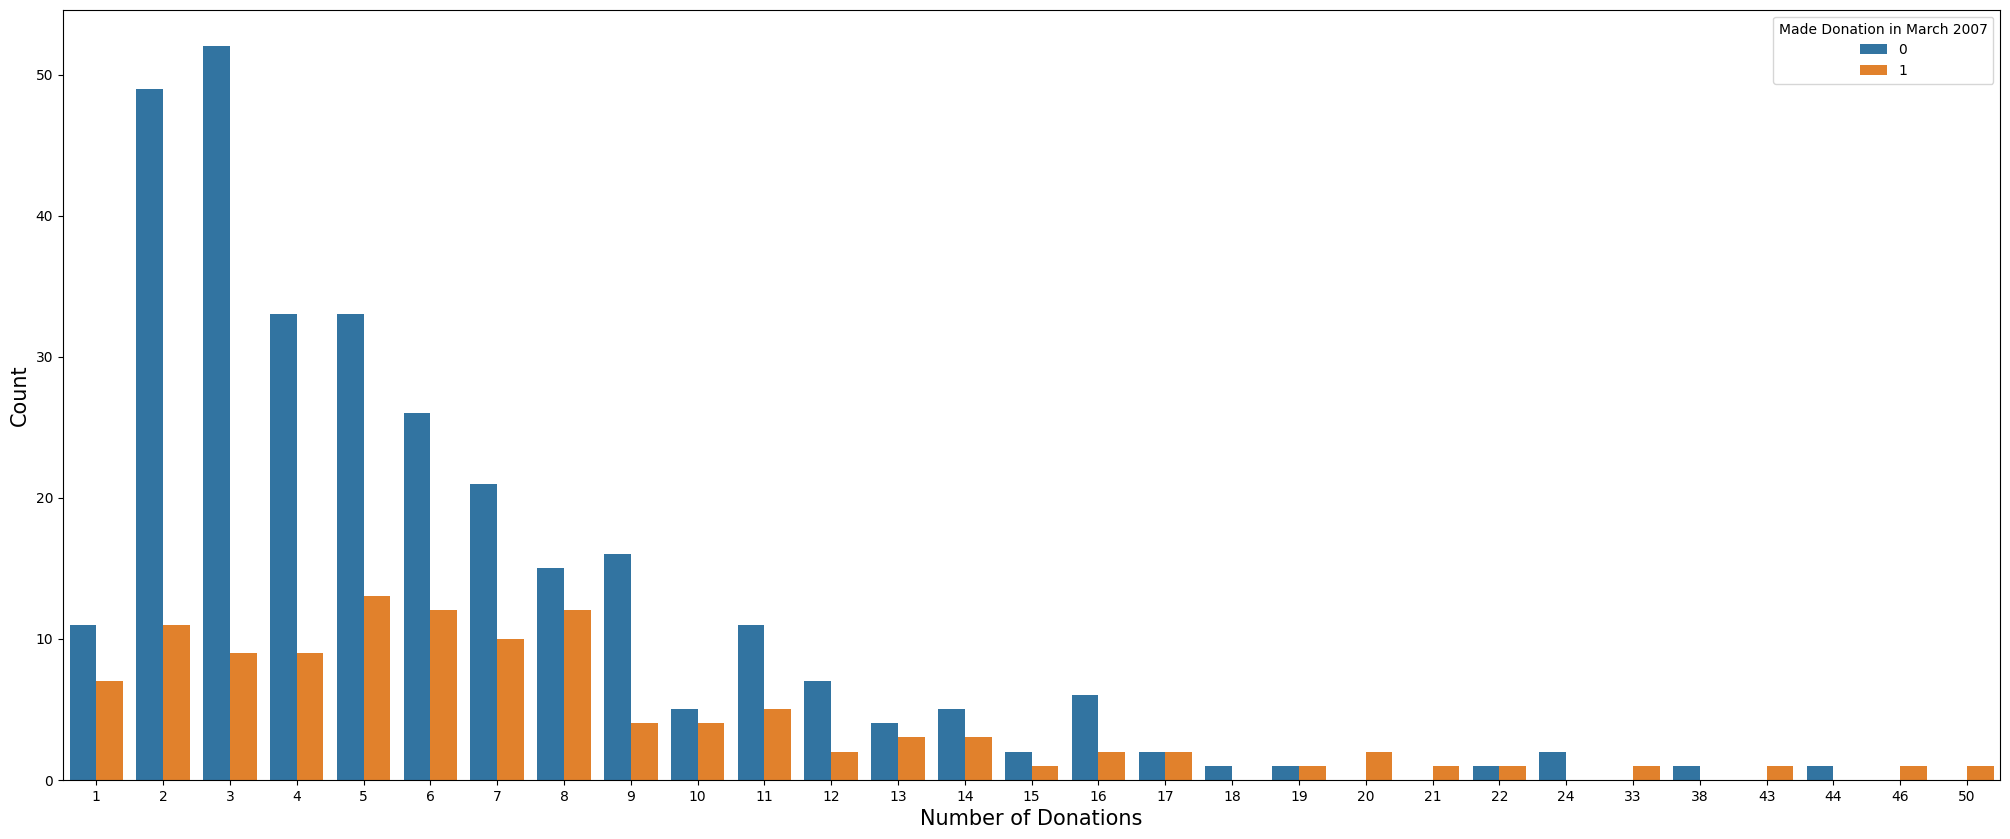

In [ ]:
#Number of Donations Vs Made Donation in March 2007
plt.figure(figsize=(25,10),facecolor="white")
sns.countplot(x="Number of Donations",hue="Made Donation in March 2007",data=Data)
plt.xlabel("Number of Donations",fontsize=15)
plt.ylabel("Count",fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show() #2

In [ ]:
#Group by "Number of Donations" and check the count of "Made Donation in March 2007"
donation_counts = Data.groupby("Number of Donations")["Made Donation in March 2007"].value_counts().unstack()

# Display the result
print(donation_counts)

Made Donation in March 2007     0     1
Number of Donations                    
1                            11.0   7.0
2                            49.0  11.0
3                            52.0   9.0
4                            33.0   9.0
5                            33.0  13.0
6                            26.0  12.0
7                            21.0  10.0
8                            15.0  12.0
9                            16.0   4.0
10                            5.0   4.0
11                           11.0   5.0
12                            7.0   2.0
13                            4.0   3.0
14                            5.0   3.0
15                            2.0   1.0
16                            6.0   2.0
17                            2.0   2.0
18                            1.0   NaN
19                            1.0   1.0
20                            NaN   2.0
21                            NaN   1.0
22                            1.0   1.0
24                            2.0   NaN


## 5.5. MULTIVARIATE ANALYSIS

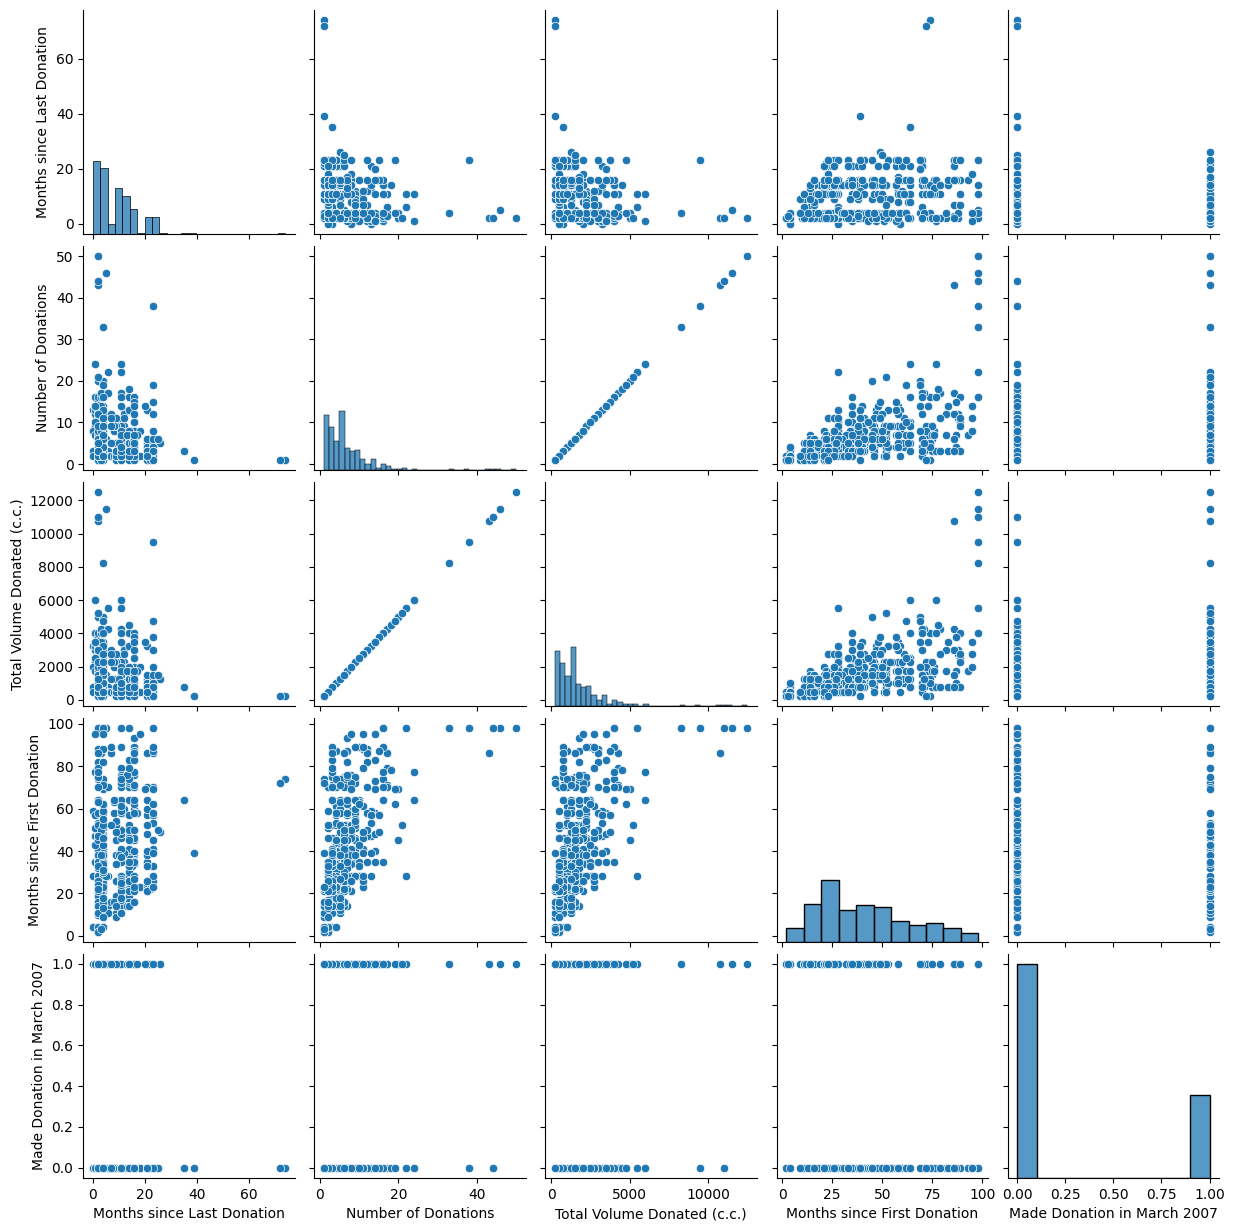

In [ ]:
#Multiple Analysis
sns.pairplot(Data)

# INSIGHTS
1. Out of a total of 423 members, 118 individuals made a donation in March 2007, while the remaining 305 did not contribute any donations during that period.
2. In this dataset, 18 individuals have made only one donation, while one person has reached a total of 50 donations.
3. Since the total volume is proportional to the number of donations, it follows the same trend. Each donation contributes 250 cc to the
total volume.
4. Individuals with 20 or more past donations had a higher donation count in March 2007.

# 6. DATA PREPROCESSING

## 6.1. CHECKING NULL VALUES

In [ ]:
#CHECKING NULL VALUE
Data.isnull().sum()

,0
Months since Last Donation,0
Number of Donations,0
Total Volume Donated (c.c.),0
Months since First Donation,0
Made Donation in March 2007,0


## 6.2. CORRELATION

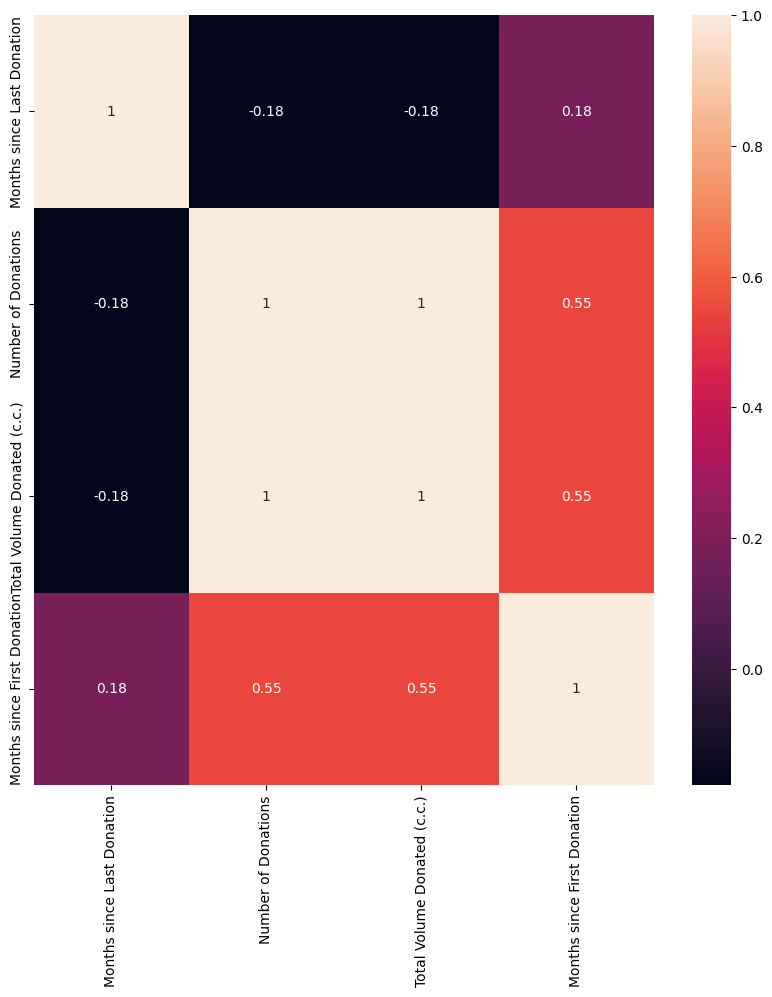

In [ ]:
# Check for correlation to avoid multicollinearity
numer=Data.select_dtypes(include=['int','float'])
plt.figure(figsize=(10,10))
sns.heatmap(data=numer.iloc[:,:-1].corr(),annot=True)
plt.show()

In [ ]:
Data.corr()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
Months since Last Donation,1.000000,-0.177813,-0.177813,0.177292,-0.254092
Number of Donations,-0.177813,1.000000,1.000000,0.548599,0.166417
Total Volume Donated (c.c.),-0.177813,1.000000,1.000000,0.548599,0.166417
Months since First Donation,0.177292,0.548599,0.548599,1.000000,-0.121118
Made Donation in March 2007,-0.254092,0.166417,0.166417,-0.121118,1.000000


## 6.3. HANDLING THE OUTLIERS

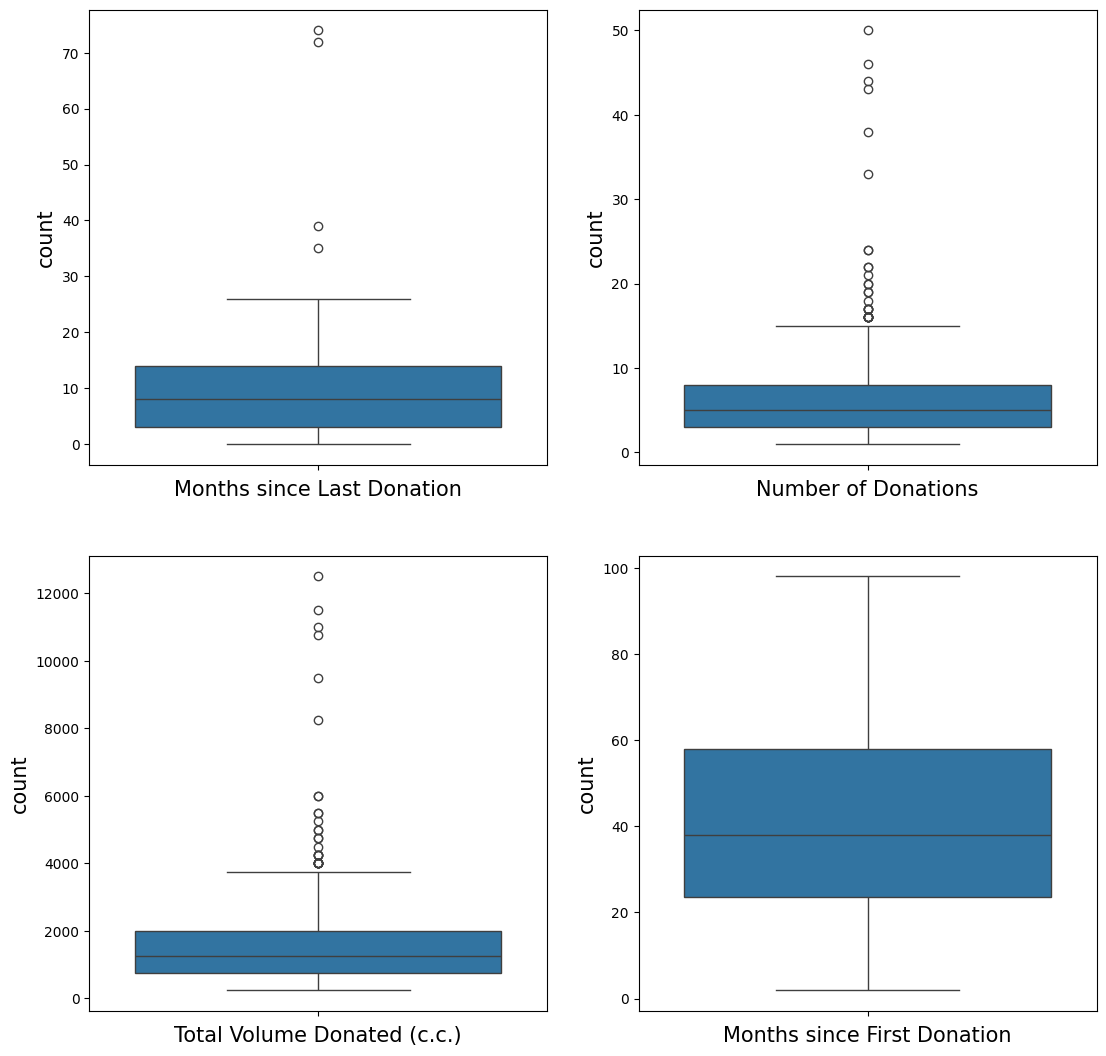

In [ ]:
#checking the outliers
numout=Data.select_dtypes(exclude="O").iloc[:,:-1]
plt.figure(figsize=(13,13),facecolor='white')
plotnumber=1
for i in numout.columns:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(numout[i])
        plt.xlabel(i,fontsize=15)
        plt.ylabel('count',fontsize=15)
    plotnumber=plotnumber+1

plt.show()

In [ ]:
# Handling the outliers

from scipy.stats.mstats import winsorize

winsor_limits = {'Months since Last Donation': (0, 0.01),
                 'Number of Donations': (0, 0.07),
                 'Total Volume Donated (c.c.)': (0, 0.07),
                 }

for col, lim in winsor_limits.items():
    Data[col] = winsorize(Data[col],limits=lim)

#### INSIGHTS

--> The outliers were handled by winsorizing the top 1% of values in Months since Last Donation and the top 7% of values in Number of Donations
and Total Volume Donated (c.c.), after running multiple iterations with different limits to identify the optimal thresholds
where extreme values were effectively adjusted while retaining the overall data distribution.

--> Additionally, no outliers were found in the Months since First Donation column, so it was not modified.

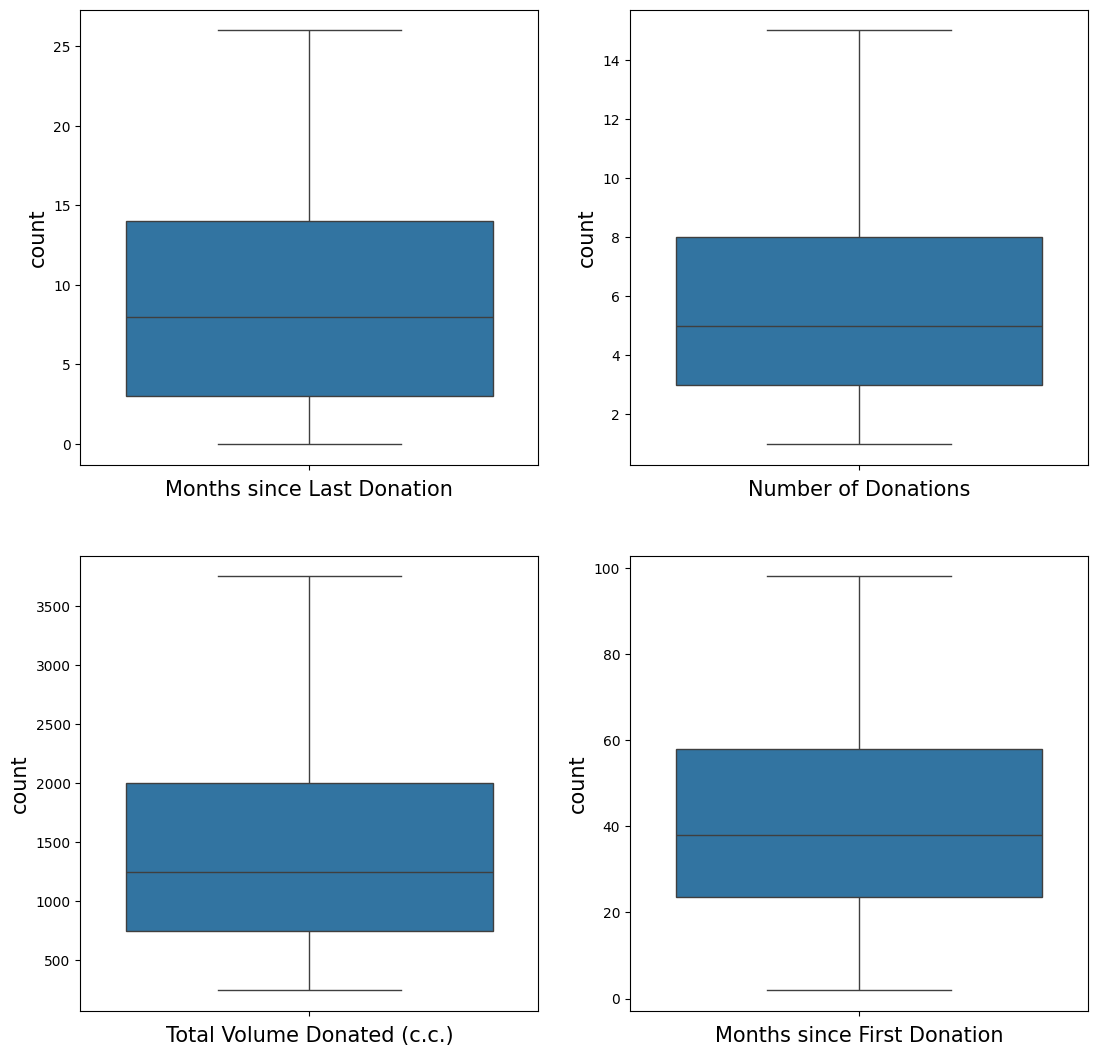

In [ ]:
# After handling the outliers and checking
numout=Data.select_dtypes(exclude="O").iloc[:,:-1]
plt.figure(figsize=(13,13),facecolor='white')
plotnumber=1
for i in numout.columns:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(numout[i])
        plt.xlabel(i,fontsize=15)
        plt.ylabel('count',fontsize=15)
    plotnumber=plotnumber+1

plt.show()


## 6.4. CLASS IMBALANCE CHECKING

In [ ]:
# Checking the value counts of the target column
class_counts=Data["Made Donation in March 2007"].value_counts()
class_counts

,count
Made Donation in March 2007,
0,305
1,118


In [ ]:
# Imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
imbalance_ratio

2.5847457627118646

#### INSIGHTS

Applying SMOTE to balance the class distribution (ratio 2.58) led to a decrease in accuracy, so it was not implemented.

## 6.5. SKEWNESS HANDLING

In [ ]:
#checking for skewness
skewness_values=Data[Data.columns[:-1]].skew()
print(skewness_values)


Months since Last Donation     0.610018
Number of Donations            0.871248
Total Volume Donated (c.c.)    0.871248
Months since First Donation    0.575577
dtype: float64


In [ ]:
# Square root transformation
Data['Months since First Donation']=np.sqrt(Data['Months since First Donation'])

#### INSIGHTS

The square root transformation was applied to Months since First Donation because it is effective in reducing right skewness while preserving the relative order of values.

In [ ]:
# Log transformation
Data[['Number of Donations','Total Volume Donated (c.c.)','Months since Last Donation']]=np.log1p(Data[['Number of Donations','Total Volume Donated (c.c.)','Months since Last Donation']])

#### INSIGHTS

The log transformation (log1p) was applied to Number of Donations, Total Volume Donated (c.c.), and Months since Last Donation because it effectively reduces right skewness, compresses the range of large values, and stabilizes variance.

In [ ]:
# Verifying after skewness handling
print(Data[Data.columns[:-1]].skew())

Months since Last Donation    -0.172215
Number of Donations           -0.006604
Total Volume Donated (c.c.)   -0.267369
Months since First Donation   -0.072977
dtype: float64


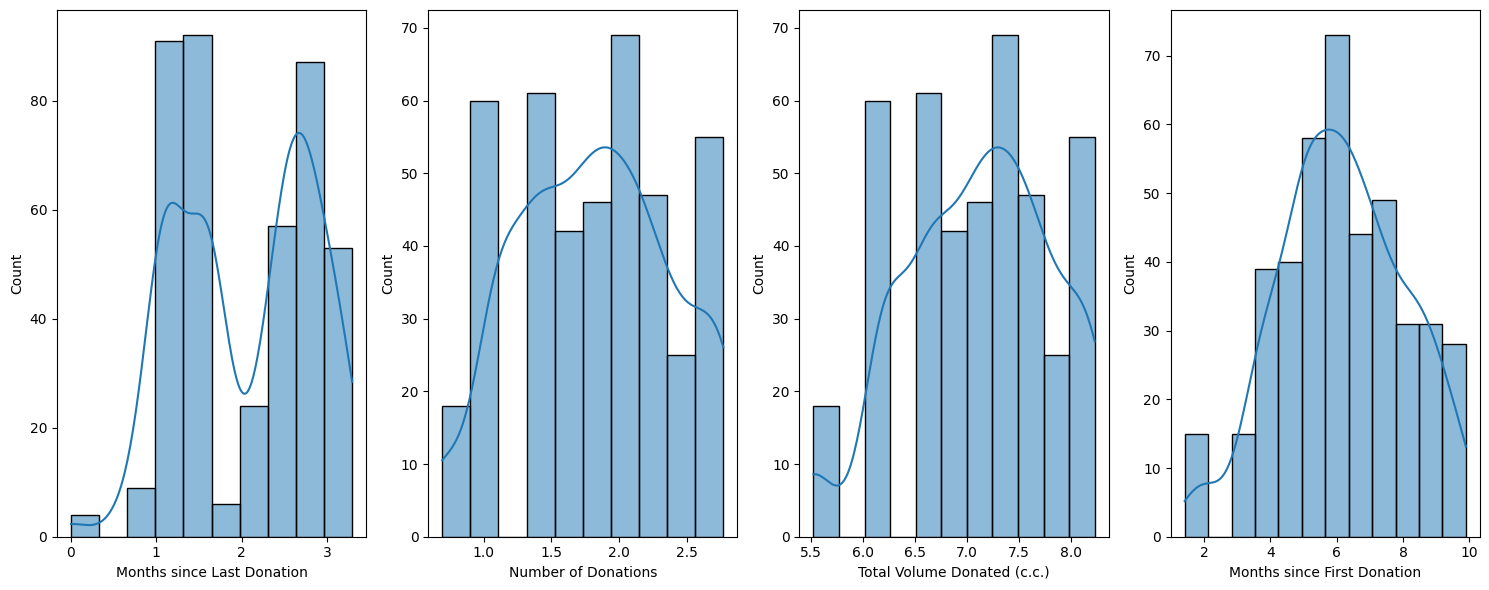

In [ ]:
# Graph after skewness handling
plt.figure(figsize=(15,6),facecolor='white')
plotnumber=1
for column in Data.columns[:-1]:
    if plotnumber<=4:
        ax=plt.subplot(1,4,plotnumber)
        sns.histplot(Data[column],kde=True)
    plotnumber+=1
plt.tight_layout()

## 6.6. SCALING THE NUMERICAL COLUMNS

In [ ]:
#extracting numerical features to scale
X=Data.drop(columns=['Made Donation in March 2007'])

In [ ]:
X

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
0,1.098612,2.772589,8.229778,9.899495
1,0.000000,2.639057,8.086718,5.291503
2,0.693147,2.772589,8.229778,5.916080
3,1.098612,2.772589,8.229778,6.708204
4,0.693147,2.772589,8.229778,8.774964
...,...,...,...,...
566,3.178054,0.693147,5.525453,4.795832
572,2.833213,1.386294,6.621406,9.273618
573,3.091042,1.098612,6.216606,7.211103
574,3.295837,0.693147,5.525453,6.244998


In [ ]:
# Initializing MinMaxScaler
Scaling=MinMaxScaler()

In [ ]:
# Scale the features
x_scale=Scaling.fit_transform(X)
scaled_data=pd.DataFrame(x_scale,columns=X.columns)
scaled_data

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
0,0.333333,1.000000,1.000000,1.000000
1,0.000000,0.935785,0.947100,0.456943
2,0.210310,1.000000,1.000000,0.530550
3,0.333333,1.000000,1.000000,0.623903
4,0.210310,1.000000,1.000000,0.867473
...,...,...,...,...
418,0.964263,0.000000,0.000000,0.398527
419,0.859634,0.333333,0.405259,0.926240
420,0.937863,0.194988,0.255573,0.683170
421,1.000000,0.000000,0.000000,0.569313


In [ ]:
x=scaled_data #numercial column

#extracting dependent feature from the data(i.e.target column)
y=Data['Made Donation in March 2007']

In [ ]:
y #Target Column

,Made Donation in March 2007
0,1
1,1
2,1
3,1
4,0
...,...
566,1
572,0
573,0
574,0


# 7. DATA SPLITTING

In [ ]:
# Splitting the training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80,random_state=13)

In [ ]:
x_train

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
163,0.859634,0.666667,0.718290,0.456943
13,0.333333,0.528321,0.593954,0.224201
119,0.488325,0.602452,0.661324,0.641280
237,0.859634,0.440643,0.511515,0.578689
152,0.753953,0.666667,0.718290,0.550194
...,...,...,...,...
230,0.821658,0.666667,0.718290,0.833333
16,0.333333,0.333333,0.405259,0.069036
74,0.333333,0.900147,0.917511,0.900521
176,0.821658,0.333333,0.405259,0.347035


In [ ]:
y_train

,Made Donation in March 2007
213,0
13,1
157,0
302,0
202,0
...,...
294,0
17,1
91,0
228,1


In [ ]:
x_test

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation
30,0.333333,0.528321,0.593954,0.304738
199,0.821658,1.000000,1.000000,1.000000
27,0.488325,0.602452,0.661324,0.304738
235,0.488325,0.194988,0.255573,0.738565
351,0.488325,0.194988,0.255573,0.258252
...,...,...,...,...
265,0.753953,0.333333,0.405259,0.860736
114,0.488325,0.528321,0.593954,0.530550
275,0.937863,0.440643,0.511515,0.683170
106,0.488325,0.602452,0.661324,0.587949


In [ ]:
y_test

,Made Donation in March 2007
34,0
254,0
31,1
300,0
464,0
...,...
340,0
151,1
360,0
143,1


# 8. MODEL CREATION

## 8.1. LOGISTIC REGRESSION

In [ ]:
# initializing the model
LR=LogisticRegression()

# fitting the training data to the model
LR.fit(x_train,y_train)

# predicting the target for testing data
y_pred_LR=LR.predict(x_test)

In [ ]:
# evaluating the model's performance by accuracy_score
lg_rg_acc=accuracy_score(y_test,y_pred_LR)
print(f'Accuracy_Score: {lg_rg_acc}')

Accuracy_Score: 0.8


## 8.2. DECISION TREE

In [ ]:
#initializing the model
DT=DecisionTreeClassifier()

#fitting the training data to the model
DT.fit(x_train,y_train)

#predicting the target for testing data
y_pred_DT=DT.predict(x_test)

In [ ]:
## Evaluating the DecisionTreeClassifier model's performance by Accuracy_Score
Dt_Accuracy_Score=accuracy_score(y_test,y_pred_DT)
print(f'Accuracy_Score:{Dt_Accuracy_Score}')

Accuracy_Score:0.6470588235294118


## 8.2.1. HYPERPARAMETER TUNING (DECISION TREE)

In [ ]:
#creating a dictionary with best parameters
params_dt={'criterion':['gini','entropy','log_loss'],
           'splitter':['best','random'],
           'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
           'min_samples_split':list(range(1,20)),
           'min_samples_leaf':list(range(1,20)),
            'max_features': ['sqrt', 'log2'],
            'max_leaf_nodes': [10, 20, 50, 100]}

In [ ]:
#initializing RandomizedSearchCV
DT_CV=RandomizedSearchCV(estimator=DT,
                   param_distributions=params_dt,
                   scoring='accuracy',
                   n_jobs=-1,
                   verbose=3,
                   cv=5
                  )

#fitting the training data to the RandomizedSearchCV
DT_CV.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'max_leaf_nodes': [10, 20, 50, 100],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19],
                                        'min_samples_split': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9, 10, 11,
                                                              12, 13, 14, 15,
                                                              16, 17, 18, 19],
                                        'splitter': ['best', 'random']},
                   scoring='accuracy', verbose=3)

In [ ]:
#getting best hyperparameters
print(f'Best_Params:{DT_CV.best_params_}')

Best_Params:{'splitter': 'random', 'min_samples_split': 5, 'min_samples_leaf': 15, 'max_leaf_nodes': 10, 'max_features': 'log2', 'max_depth': 7, 'criterion': 'entropy'}


In [ ]:
#initializing DecisionTreeClassifier model
DT_Model=DecisionTreeClassifier(splitter= 'random', min_samples_split=5, min_samples_leaf= 15, max_leaf_nodes= 10,
max_features='log2', max_depth= 7, criterion= 'entropy')
#fitting the training data to the model
DT_Model.fit(x_train,y_train)

#predicting the target for testing data
predd_dt=DT_Model.predict(x_test)

#Evaluating the DecisionTreeClassifier model's performance by Accuracy_Score
dt_acc=accuracy_score(y_test,predd_dt)
print(f'Accuracy_Score: {dt_acc}')

Accuracy_Score: 0.8352941176470589


## 8.3. RANDOM FOREST

In [ ]:
#initializing randomforest model
RF=RandomForestClassifier()

#fitting the training data to the model
RF.fit(x_train,y_train)

#predicting the target for testing data
pred_rf=RF.predict(x_test)

In [ ]:
#evaluating the RandomForestClassifier model's performance by Accuracy_Score
Rf_Accuracy_Score=accuracy_score(y_test,pred_rf)
print(f'Accuracy_Score:{Rf_Accuracy_Score}')

Accuracy_Score:0.7294117647058823


## 8.3.1. HYPERPARAMETER TUNING (RANDOM FOREST)

In [ ]:
#creating a dictionary with best parameters
params_rf={'n_estimators': [50,100,150,200,250,300,350,400,450,500],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': list(range(1,51)),
    'min_samples_split': list(range(1,30)),
    'min_samples_leaf': list(range(1,30)),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'oob_score': [True, False],
    'class_weight': [None, 'balanced']
       }

In [ ]:
#initializing RandomizedSearchCV
RF_CV=RandomizedSearchCV(estimator=RF,
                   param_distributions=params_rf,
                   scoring='accuracy',
                   cv=5,
                   verbose=3,
                   n_jobs=-1
                  )

#fitting the training data into RandomizedSearchCV
RF_CV.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': [None, 'balanced'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, ...],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19, 20, 21,
                                                             22, 23, 24, 25, 26,
                                                             27, 28, 29],
                                        'min_samples_split': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9, 10, 11,
                                                              12, 13, 14, 15,
                                                              16, 17, 18, 19,
                                                              20, 21, 22, 23,
                                                              24, 25, 26, 27,
                                                              28, 29],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 350, 400, 450,
                                                         500],
                                        'oob_score': [True, False]},
                   scoring='accuracy', verbose=3)

In [ ]:
#getting a best hyperparameter
print(f'Best_Params:{RF_CV.best_params_}')

Best_Params:{'oob_score': False, 'n_estimators': 50, 'min_samples_split': 23, 'min_samples_leaf': 19, 'max_features': 'log2', 'max_depth': 28, 'criterion': 'gini', 'class_weight': None, 'bootstrap': False}


In [ ]:
#initializing RandomForest model
#max_depth=9, max_features='sqrt', min_samples_leaf=5, min_samples_split=4, n_estimators=300
RF_Model=RandomForestClassifier(oob_score= False, n_estimators= 50, min_samples_split= 23, min_samples_leaf= 19, max_features= "log2", max_depth= 28,
criterion='gini', class_weight= None, bootstrap= False)

#fitting the training data to the model
RF_Model.fit(x_train,y_train)

#predicting the target for testing data
pred_rf1=RF_Model.predict(x_test)

#evaluating RandomForestClassifier model's performance by Accuracy_Score
rf_acc=accuracy_score(y_test,pred_rf1)
print(f'Accuracy_Score:{rf_acc}')

Accuracy_Score:0.8117647058823529


In [ ]:
#oob_score= False, n_estimators= 350, min_samples_split= 17, min_samples_leaf= 15, max_features= None, max_depth= 15,
#criterion='entropy', class_weight= None, bootstrap= True - 0.8117647058823529



## 8.4. GRADIENT BOOSTING CLASSIFIER

In [ ]:
gbmodel=GradientBoostingClassifier()
gbmodel.fit(x_train,y_train)
y_pred_gb=gbmodel.predict(x_test)


In [ ]:
#evaluating the XGboostClassifier model's performance by Accuracy_Score
GB_accuracy=accuracy_score(y_test,y_pred_gb)
print(f'Accuracy_Score: {GB_accuracy}')

Accuracy_Score: 0.7294117647058823


## 8.4.1. HYPERPARAMETER TUNING (GRADIENT BOOSTING)

In [ ]:
gb1grid = {
     'n_estimators': [50,100,150,200,250,300,350,400,450,500],
    'learning_rate': [0.0001,0.01,0.02,0.03,0.1,0.2],
    'max_depth': list(range(1,20)),
    'min_samples_split': list(range(1,20)),
    'min_samples_leaf': list(range(1,20)),
    'max_features': ['sqrt', 'log2']
}

gbc=GradientBoostingClassifier()
gb1_cv=RandomizedSearchCV(estimator=gbc,scoring='accuracy',param_distributions=gb1grid,cv=5,verbose=2,n_jobs=-1)
gb1_cv.fit(x_train,y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.0001, 0.01, 0.02,
                                                          0.03, 0.1, 0.2],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19],
                                        'min_samples_split': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9, 10, 11,
                                                              12, 13, 14, 15,
                                                              16, 17, 18, 19],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 350, 400, 450,
                                                         500]},
                   scoring='accuracy', verbose=2)

In [ ]:
bestparamssgb=gb1_cv.best_params_
print(f'best_params:{bestparamssgb}')

best_params:{'n_estimators': 450, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_depth': 2, 'learning_rate': 0.02}


In [ ]:
gbk=GradientBoostingClassifier(n_estimators=450, min_samples_split=10, min_samples_leaf=7, max_features='sqrt', max_depth=2, learning_rate=0.02)
gbk.fit(x_train,y_train)
ypred_gbk=gbk.predict(x_test)
gb_acc=accuracy_score(y_test,ypred_gbk)
print(f'Accuracy_Score:{gb_acc}')

Accuracy_Score:0.8235294117647058


# 8.5. XGBOOSTING CLASSIFIER

In [ ]:
#initializing XGBClassifier
XGB=XGBClassifier()

#fitting the training data to the model
XGB.fit(x_train,y_train)

#predicting the target for testing data
pred_XGB=XGB.predict(x_test)

In [ ]:
#evaluating the XGboostClassifier model's performance by Accuracy_Score
XGB_accuracy=accuracy_score(y_test,pred_XGB)
print(f'Accuracy_Score:{XGB_accuracy}')

Accuracy_Score:0.6823529411764706


## 8.5.1. HYPERPARAMETER TUNING (XGBOOSTING)

In [ ]:
#creating a dictionary with hyperparameter
params={'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 300],
        'max_depth': list(range(1,50)),
        'gamma': [0, 0.1, 0.2],
        'reg_alpha':[0.0,0.1,0.5,1.0]
       }

In [ ]:
#initializing RandomizedSearchCV
XGB_CV=RandomizedSearchCV(estimator=XGB,
                   param_distributions=params,
                   scoring='accuracy',
                   cv=3,
                   n_jobs=-1,
                   verbose=1)

#fitting the training data into RandomizedSearchCV
XGB_CV.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_jobs=-1,
                   param_distributions={'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, ...],
                                        'n_estimators': [100, 200, 300],
                                        'reg_alpha': [0.0, 0.1, 0.5, 1.0]},
                   scoring='accuracy', verbose=1)

In [ ]:
#getting a best hyperparameter
print(f'Best_Params:{XGB_CV.best_params_}')

Best_Params:{'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.2}


In [ ]:
#initializing RandomForest model
XGB_Model=XGBClassifier(reg_alpha=1.0, gamma=0.2, learning_rate=0.1, max_depth=4, n_estimators=200)

#fitting the training data to the model
XGB_Model.fit(x_train,y_train)

#predicting the target for testing data
pred_XGB_best=XGB_Model.predict(x_test)

In [ ]:
#evaluating the XGboostClassifier model's performance by Accuracy_Score
xg_acc=accuracy_score(y_test,pred_XGB_best)
print(f'Accuracy_Score:{xg_acc}')

Accuracy_Score:0.8


## 8.6. SVC [SUPPORT VECTOR CLASSIFIER]

In [ ]:
#initialiazing SVC model
svc_=SVC()

#fitting the training data to the model
svc_.fit(x_train,y_train)

#predicting the target for the training data
pred_svc=svc_.predict(x_test)

In [ ]:
#evaluating the SVC model's performance by Accuracy_Score
SVC_accuracy=accuracy_score(y_test,pred_svc)
print(f'Accuracy_Score: {SVC_accuracy}')

Accuracy_Score: 0.8470588235294118


## 8.6.1.  HYPERPARAMETER TUNING (SVC)

In [ ]:
# Creating a dictionary with possible Hyperparameters
params={'kernel':['linear','rbf'],
        'degree':[1,2,3,4,5],
        'gamma':['scale', 'auto'],
        'C':[0.1, 1, 10, 100]
        }

In [ ]:
#initializing RandomizedSearchCV
SVC_CV=RandomizedSearchCV(estimator=svc_,
                    param_distributions=params,
                    scoring='accuracy',
                    cv=5,verbose=3,
                    n_jobs=-1)

#fitting a training data into RandomizeddSearchCV
SVC_CV.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'degree': [1, 2, 3, 4, 5],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf']},
                   scoring='accuracy', verbose=3)

In [ ]:
#getting a best parameter
print(f'Best Parameters:{SVC_CV.best_params_}')

Best Parameters:{'kernel': 'rbf', 'gamma': 'scale', 'degree': 2, 'C': 1}


In [ ]:
#intializing the model
SVC_Model=SVC(C=1, degree=2, gamma='scale', kernel='rbf')

#fitting the training data to the model
SVC_Model.fit(x_train,y_train)

#predicting the target for the testing data
pred_svc_best=SVC_Model.predict(x_test)

#evaluating the SVC model's performance by Accuracy_Score
svc_acc=accuracy_score(y_test,pred_svc_best)
print(f'Accuracy_Score:{svc_acc}')

Accuracy_Score:0.8470588235294118


## 8.7. KNN [K-NEAREST NEIGHBORS]

In [ ]:
#initialiazing knn model
knn_=KNeighborsClassifier()

#fitting the training data to the model
knn_.fit(x_train,y_train)

#predicting the target for the training data
y_pred_knn=knn_.predict(x_test)

In [ ]:
#evaluating the SVC model's performance by Accuracy_Score
KNN_accuracy=accuracy_score(y_test,y_pred_knn)
print(f'Accuracy_Score: {KNN_accuracy}')

Accuracy_Score: 0.7647058823529411


## 8.7.1. HYPERPARAMETER TUNING (KNN)

In [ ]:
# Creating a dictionary with possible Hyperparameters
knnn_paramss={
    'n_neighbors': [1,2,3,4,5,6, 7,8, 9,10, 11,12,13,14, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': list(range(1,51))
}

k=KNeighborsClassifier()
knn1=RandomizedSearchCV(estimator=k,param_distributions=knnn_paramss,scoring='accuracy',n_jobs=-1,verbose=2,cv=5)
knn1.fit(x_train,y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'leaf_size': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, ...],
                                        'metric': ['euclidean', 'manhattan',
                                                   'minkowski'],
                                        'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10, 11, 12, 13, 14,
                                                        15],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   scoring='accuracy', verbose=2)

In [ ]:
#getting a best parameter
bestparams_knn=knn1.best_params_
print(f'best_parameters:{bestparams_knn}')

best_parameters:{'weights': 'uniform', 'p': 1, 'n_neighbors': 14, 'metric': 'euclidean', 'leaf_size': 47, 'algorithm': 'ball_tree'}


In [ ]:
#intializing the model
knn_model1=KNeighborsClassifier(weights= 'uniform', p= 1, n_neighbors= 14, metric='euclidean', leaf_size= 47, algorithm= 'ball_tree')

#fitting the training data to the model
knn_model1.fit(x_train,y_train)
y_pred_knn1=knn_model1.predict(x_test)
knn_acc=accuracy_score(y_test,y_pred_knn1)
print(f'Accuracy_Score:{knn_acc}')

Accuracy_Score:0.8117647058823529


## 8.8. ANN [ARTIFICIAL NEURAL NETWORK]

In [ ]:
ann_=MLPClassifier()
ann_.fit(x_train,y_train)
ypred_ann=ann_.predict(x_test)

In [ ]:
#evaluating the SVC model's performance by Accuracy_Score
ANN_accuracy=accuracy_score(y_test,ypred_ann)
print(f'Accuracy_Score: {ANN_accuracy}')

Accuracy_Score: 0.8


## 8.8.1. HYPERPARAMETER TUNING (ANN)

In [ ]:
ann_param_grid = {'hidden_layer_sizes': [(100,),(200,),(300,),(400,),(500,),(1000,) ],
              'activation': ['relu', 'tanh', 'logistic'],
              'solver': ['adam', 'lbfgs'],
              'alpha': [0.0001, 0.001, 0.01],
              'learning_rate_init': [0.001, 0.01, 0.1]}

mlp=MLPClassifier()
ann1=RandomizedSearchCV(estimator=mlp,param_distributions=ann_param_grid,scoring='f1',n_jobs=-1,verbose=2,cv=5)
ann1.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=MLPClassifier(), n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh',
                                                       'logistic'],
                                        'alpha': [0.0001, 0.001, 0.01],
                                        'hidden_layer_sizes': [(100,), (200,),
                                                               (300,), (400,),
                                                               (500,),
                                                               (1000,)],
                                        'learning_rate_init': [0.001, 0.01,
                                                               0.1],
                                        'solver': ['adam', 'lbfgs']},
                   scoring='f1', verbose=2)

In [ ]:
bestparams_ann=ann1.best_params_
print(f'best_parameters:{bestparams_ann}')

best_parameters:{'solver': 'lbfgs', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (300,), 'alpha': 0.001, 'activation': 'tanh'}


In [ ]:
ann_model2=MLPClassifier(solver= 'lbfgs',learning_rate_init= 0.001, hidden_layer_sizes= (300,), alpha= 0.001, activation= 'tanh')
ann_model2.fit(x_train,y_train)
ypred_ann2=ann_model2.predict(x_test)
ann_acc=accuracy_score(y_test,ypred_ann2)
print(f'Accuracy_Score:{ann_acc}')

Accuracy_Score:0.8


# 9.MODEL COMPARISON REPORT

In [ ]:
comparison_dict = {
    'Model': ['LogisticRegression', 'DecisionTreeClassifier', 'RandomForest', 'GradientBoost', 'XGBoost', 'KNearestNeighbors',
              'MLPClassifier','SVClassifier'],
    'Accuracy_score': [lg_rg_acc, dt_acc, rf_acc, gb_acc, xg_acc, knn_acc, ann_acc, svc_acc]
}

comparison_df = pd.DataFrame(comparison_dict)
print(comparison_df)

                    Model  Accuracy_score
0      LogisticRegression        0.800000
1  DecisionTreeClassifier        0.835294
2            RandomForest        0.811765
3           GradientBoost        0.823529
4                 XGBoost        0.800000
5       KNearestNeighbors        0.811765
6           MLPClassifier        0.800000
7            SVClassifier        0.847059


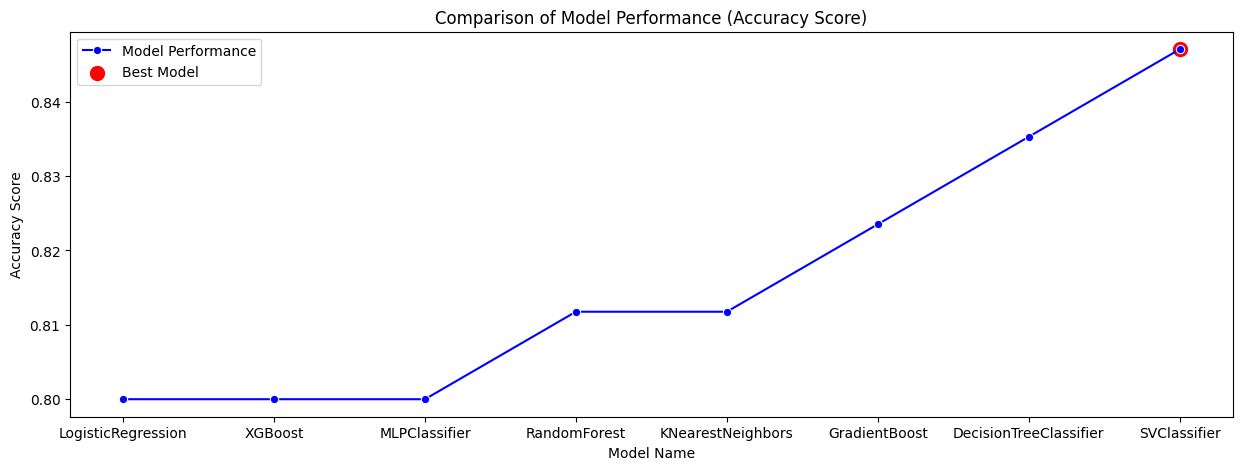

In [ ]:
comparison_df = comparison_df.sort_values(by='Accuracy_score', ascending=True)

max_index = comparison_df['Accuracy_score'].idxmax()

plt.figure(figsize=(15, 5))

# Line plot for accuracy scores
sns.lineplot(data=comparison_df, x='Model', y='Accuracy_score', marker='o', color='blue', label="Model Performance")

plt.scatter(comparison_df.loc[max_index, 'Model'], comparison_df.loc[max_index, 'Accuracy_score'],
            color='red', s=100, label="Best Model")

plt.xlabel("Model Name")
plt.ylabel("Accuracy Score")

plt.legend()
plt.title("Comparison of Model Performance (Accuracy Score)")
plt.show()

# 10. CONCLUSION

*  From the line plot, Support Vector Classifier and Decision Tree Classifier demonstrate the best performance . Their high accuracy suggests that they are well-suited for this classification problem compared to other models.

*  Among all the models, 'SVClassifier' has the highest predictive performance. Therefore, we can infer that 'Support Vector Classifier' will be the most suitable model for the given dataset.
   



# 11.CHALLENGES FACED
1. Extracting insights from the dataset.
2. checking the duplicated values from the dataset.
3. checking the outlier of the dataset.
4. handling the skewness in the dataset
5. Took more computational time for some models.
6. Addressing at which random_state all models can perform mutually well.